### RaschPy thresholds MFRM worked example

This notebook works through a sample Rasch analysis of a simulated data set (200 persons, 8 items with a maximum score of 5, all rated by 8 raters, no missing data), taking you through the relevant commands step by step, with notes before each cell. Relevant outputs will appear below each cell.

Under the thresholds parameterisation, each rater has a separate severity for every threshold (shared across items), rather than a single scalar severity as in the global model.

Import the modules and set the working directory (here called `my_working_directory`) to where you want to save your output files.

In [1]:
import raschpy as rp
import os

os.chdir('my_working_directory')

**A note on data validation**

Every model constructor validates the item-response network automatically at instantiation (`validate=True` by default) and warns if it's disconnected — if there's no chain of persons and items linking every item to every other, the resulting item locations aren't on a common scale, even though `calibrate()` will still run without error. This is worth seeing happen once. Here we build a small, deliberately disconnected data set: two groups of persons who each only answer a disjoint set of items, with no item shared between the groups to link them:

In [2]:
sim_disconnected = rp.MFRM_Sim_Thresholds(no_of_items=8, no_of_persons=40, no_of_raters=4, max_score=5, seed=99)
responses_disconnected = sim_disconnected.responses.copy()
persons = responses_disconnected.index.get_level_values(1).unique()
group_a, group_b = persons[:20], persons[20:]
responses_disconnected.loc[(slice(None), group_a), responses_disconnected.columns[4:]] = float('nan')   # group A: only items 1-4
responses_disconnected.loc[(slice(None), group_b), responses_disconnected.columns[:4]] = float('nan')    # group B: only items 5-8

broken_mfrm = rp.MFRM(responses_disconnected)   # raises a UserWarning

/Users/markelliott/Documents/GitHub/RaschPy/raschpy/mfrm.py:341: UserWarning: The data is split into 2 disconnected sub-networks. This will break un-smoothed calibrations. Isolated groupings: Sub-group 1 (size 4): ['Item_1', 'Item_2', 'Item_3', 'Item_4']; Sub-group 2 (size 4): ['Item_5', 'Item_6', 'Item_7', 'Item_8']
  self.connectivity_status = self.check_data_connectivity()
/var/folders/hs/f4mv8_3d65bf5fln8jlxhxpc0000gn/T/ipykernel_52656/400418962.py:8: UserWarning: 
⚠️  CRITICAL DATA INTEGRITY WARNING: The response data is disconnected into 2 separate sub-networks.
Item location estimates will be problematic because there are no empirical comparisons spanning across these isolated groups, the item parameter estimates for each independent subset will separately sum to zero. This means items belonging to different subsets cannot be compared or calibrated onto a single scale.
  broken_mfrm = rp.MFRM(responses_disconnected)   # raises a UserWarning


`connectivity_status` records the diagnosis, including which items ended up in which isolated sub-group:

In [3]:
broken_mfrm.connectivity_status

{'connected': False,
 'components_count': 2,
 'isolated_items': [],
 'all_sub_groups': [['Item_1', 'Item_2', 'Item_3', 'Item_4'],
  ['Item_5', 'Item_6', 'Item_7', 'Item_8']],
 'directionally_isolated_items': []}

The rest of this notebook uses a single, fully-connected simulated data set, so this warning won't come up again.

Simulate a data set. Passing `seed=42` makes the simulation fully reproducible — rerunning this notebook will always generate the same data set.

In [4]:
sim = rp.MFRM_Sim_Thresholds(no_of_items=8, no_of_persons=200, no_of_raters=8, max_score=5, missing=0, seed=42)
sim.responses.to_csv('mfrm_thresholds_scores.csv')

If you have your own response data saved to a CSV file instead of simulating it, use `loadup_mfrm_single()` to load and validate it. Demonstrated here by reloading the file we just saved:

In [5]:
data, invalid_responses = rp.loadup_mfrm_single('mfrm_thresholds_scores.csv', max_score=5)

Check the data - view the first two lines

In [6]:
data.head(2)

Item_1  Item_2  Item_3  Item_4  Item_5  Item_6  Item_7  \
Rater   Person                                                             
Rater_1 Person_1     5.0     5.0     4.0     3.0     3.0     3.0     3.0   
        Person_2     3.0     2.0     3.0     2.0     4.0     2.0     1.0   

                  Item_8  
Rater   Person            
Rater_1 Person_1     1.0  
        Person_2     2.0

Check for any invalid responses (not usable for estimation purposes and excluded)

In [7]:
invalid_responses

,,Item_1,Item_2,Item_3,Item_4,Item_5,Item_6,Item_7,Item_8
Rater,Person,,,,,,,,


Create an MFRM object. Passing the simulation object `sim` directly (rather than the reloaded `data`) attaches the generating parameters under `mfrm.generating`, which lets us check parameter recovery further down. If you're analysing your own data, pass a DataFrame instead (e.g. `rp.MFRM(data)`).

In [8]:
mfrm = rp.MFRM(sim)

Calibrate under the thresholds parameterisation (a separate severity per rater x threshold combination, shared across items). The `%%time` "magic function" returns the time taken to run the cell contents (algorithm run time in this case).

In [9]:
%%time
mfrm.calibrate_thresholds()

CPU times: user 2.32 ms, sys: 225 μs, total: 2.55 ms
Wall time: 2.41 ms


Check the item location estimates - view the first two items

In [10]:
mfrm.items.head(2)

Item_1   -1.030786
Item_2   -0.445861
dtype: float64

Since this is simulated data, we know the true generating item locations and can check how closely the calibration recovered them. The helper below plots generating vs. estimated values, with an identity line (dashed dark red) and a fitted regression line (dashed red) — the closer the points hug the identity line, the better the recovery — alongside the Pearson correlation, SD ratio, regression coefficient, and RMSE:

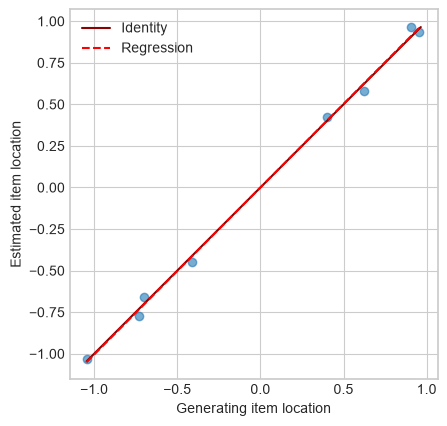

item location Pearson correlation:              0.999
item location SD ratio (estimated / generating): 1.007
item location regression coefficient:            1.005
item location RMSE:                              0.038


In [11]:
import numpy as np
from matplotlib import pyplot as plt

def recovery_plot(generating, estimated, label, filename):
    x, y = np.asarray(generating), np.asarray(estimated)
    fig, ax = plt.subplots()
    ax.scatter(x, y, alpha=0.6)
    lo, hi = min(x.min(), y.min()), max(x.max(), y.max())
    ax.plot([lo, hi], [lo, hi], color='DarkRed', label='Identity')
    m, b = np.polyfit(x, y, 1)
    ax.plot([lo, hi], [m * lo + b, m * hi + b], color='Red', linestyle='--', label='Regression')
    ax.set_xlabel(f'Generating {label}')
    ax.set_ylabel(f'Estimated {label}')
    ax.set_aspect('equal')
    ax.legend()
    plt.savefig(filename)
    plt.show()
    print(f'{label} Pearson correlation:              {round(np.corrcoef(x, y)[0, 1], 3)}')
    print(f'{label} SD ratio (estimated / generating): {round(y.std() / x.std(), 3)}')
    print(f'{label} regression coefficient:            {round(m, 3)}')
    print(f'{label} RMSE:                              {round(np.sqrt(((x - y) ** 2).mean()), 3)}')

recovery_plot(sim.items, mfrm.items, 'item location', 'my_mfrm_thresholds_item_recovery.png')

Generate a table of item statistics (and check run time), and save to file

In [12]:
%%time
mfrm.item_stats_df_thresholds()
mfrm.item_stats_thresholds.to_csv('mfrm_thresholds_item_stats.csv')

CPU times: user 2.62 s, sys: 47.6 ms, total: 2.67 s
Wall time: 2.68 s


Check the item statistics table - view the first two items

In [13]:
mfrm.item_stats_thresholds.head(2)

,Estimate,SE,Count,Facility,Infit MS,Outfit MS
Item_1,-1.031,0.044,1600,0.650,1.028,1.026
Item_2,-0.446,0.037,1600,0.572,1.060,1.052


Generate a table of threshold statistics (and check run time), and save to file

In [14]:
%%time
mfrm.threshold_stats_df_thresholds()
mfrm.threshold_stats_thresholds.to_csv('mfrm_thresholds_threshold_stats.csv')

CPU times: user 52.5 ms, sys: 1.46 ms, total: 53.9 ms
Wall time: 53.8 ms


Check the threshold statistics table - view the first two thresholds

In [15]:
mfrm.threshold_stats_thresholds.head(2)

,Estimate,SE,Infit MS,Outfit MS
Threshold 1,-2.316,0.063,1.020,1.020
Threshold 2,-1.805,0.044,1.006,1.004


And the same recovery check for thresholds, against `sim.thresholds`:

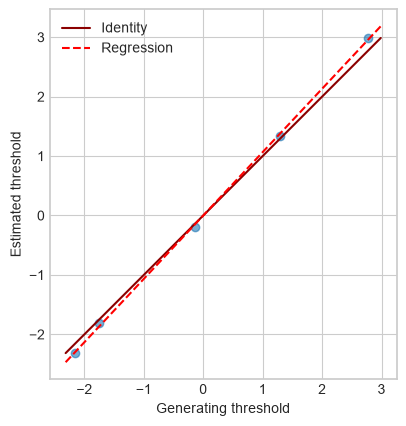

threshold Pearson correlation:              1.0
threshold SD ratio (estimated / generating): 1.066
threshold regression coefficient:            1.066
threshold RMSE:                              0.13


In [16]:
recovery_plot(sim.thresholds, mfrm.thresholds, 'threshold', 'my_mfrm_thresholds_threshold_recovery.png')

Generate a table of rater statistics (and check run time), and save to file

In [17]:
%%time
mfrm.rater_stats_df_thresholds()
mfrm.rater_stats_thresholds.to_csv('mfrm_thresholds_rater_stats.csv')

CPU times: user 25.6 ms, sys: 753 μs, total: 26.4 ms
Wall time: 26.3 ms


Check the rater statistics table - view the first two raters

In [18]:
mfrm.rater_stats_thresholds.head(2)

Threshold 1        Threshold 2        Threshold 3        Threshold 4  \
           Estimate     SE    Estimate     SE    Estimate     SE    Estimate   
Rater_1      -0.583  0.123       0.808  0.095      -0.029  0.099      -0.406   
Rater_2       0.154  0.115       0.777  0.100      -0.139  0.078       0.406   

              Threshold 5        Overall statistics                     
           SE    Estimate     SE              Count Infit MS Outfit MS  
Rater_1  0.09      -0.169  0.139             1600.0    1.030     1.029  
Rater_2  0.10      -0.884  0.135             1600.0    1.108     1.091

And the same recovery check for rater x threshold severities, against `sim.facet_effects`. Since these are per rater x threshold, we flatten with `.unstack()` first:

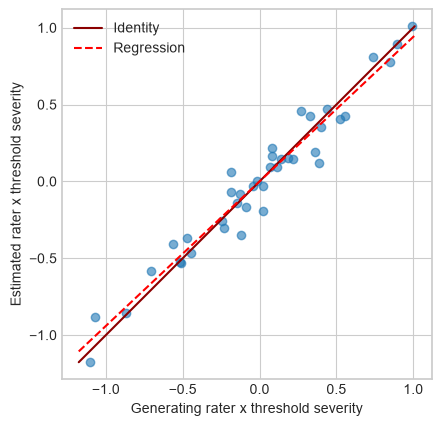

rater x threshold severity Pearson correlation:              0.974
rater x threshold severity SD ratio (estimated / generating): 0.966
rater x threshold severity regression coefficient:            0.94
rater x threshold severity RMSE:                              0.113


In [19]:
orig_severities = sim.facet_effects.unstack()
est_severities = mfrm.raters_thresholds.unstack()
recovery_plot(orig_severities, est_severities, 'rater x threshold severity', 'my_mfrm_thresholds_rater_recovery.png')

Generate a table of person statistics (and check run time), and save to file

In [20]:
%%time
mfrm.person_stats_df_thresholds()
mfrm.person_stats_thresholds.to_csv('mfrm_thresholds_person_stats.csv')

CPU times: user 8.17 ms, sys: 923 μs, total: 9.09 ms
Wall time: 8.99 ms


Check the person statistics table - view the first two persons

In [21]:
mfrm.person_stats_thresholds.head(2)

,Estimate,CSEM,Score,Max score,p,Infit MS,Outfit MS
Person_1,0.560,0.156,190,320,0.594,1.526,1.538
Person_2,-1.492,0.149,99,320,0.309,1.091,1.053


And the same recovery check for person locations, against `sim.persons`:

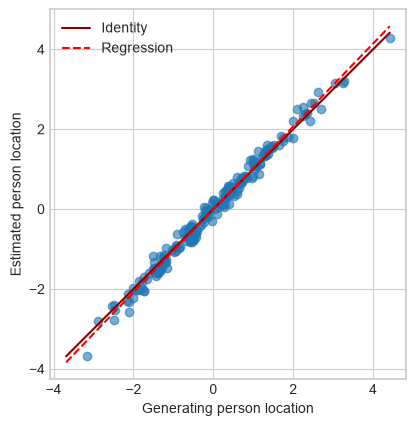

person location Pearson correlation:              0.994
person location SD ratio (estimated / generating): 1.044
person location regression coefficient:            1.038
person location RMSE:                              0.16


In [22]:
recovery_plot(sim.persons, mfrm.persons_thresholds, 'person location', 'my_mfrm_thresholds_person_recovery.png')

Generate a table of test-level statistics (and check run time), and save to file

In [23]:
%%time
mfrm.test_stats_df_thresholds()
mfrm.test_stats_thresholds.to_csv('mfrm_thresholds_test_stats.csv')

CPU times: user 1.78 ms, sys: 446 μs, total: 2.23 ms
Wall time: 2.13 ms


Check the test statistics table

In [24]:
mfrm.test_stats_thresholds

,Items,Persons
Mean,0.000,-0.008
SD,0.812,1.382
Separation ratio,19.514,8.519
Strata,26.352,11.692
Reliability,0.997,0.986


Run an item residual correlation analysis (and check run time), and save relevant output to file

In [25]:
%%time
mfrm.item_res_corr_analysis_thresholds()
mfrm.item_residual_correlations_thresholds.to_csv('mfrm_thresholds_item_residual_correlations.csv')
mfrm.item_loadings_thresholds.to_csv('mfrm_thresholds_item_loadings.csv')

CPU times: user 4.48 ms, sys: 1.67 ms, total: 6.15 ms
Wall time: 7.27 ms


View the table of pairwise standard residual correlations (pairwise local item independence check)

In [26]:
mfrm.item_residual_correlations_thresholds

,Item_1,Item_2,Item_3,Item_4,Item_5,Item_6,Item_7,Item_8
Item_1,1.000000,-0.004630,-0.020878,-0.043275,-0.007076,-0.020907,-0.071328,0.003985
Item_2,-0.004630,1.000000,-0.007113,0.028502,-0.031342,-0.019008,-0.009121,0.025265
Item_3,-0.020878,-0.007113,1.000000,-0.014553,-0.013602,0.011108,0.004983,0.005621
Item_4,-0.043275,0.028502,-0.014553,1.000000,0.030340,-0.032778,-0.004117,-0.028244
Item_5,-0.007076,-0.031342,-0.013602,0.030340,1.000000,-0.055346,-0.012388,0.008530
Item_6,-0.020907,-0.019008,0.011108,-0.032778,-0.055346,1.000000,-0.016888,-0.005284
Item_7,-0.071328,-0.009121,0.004983,-0.004117,-0.012388,-0.016888,1.000000,0.001319
Item_8,0.003985,0.025265,0.005621,-0.028244,0.008530,-0.005284,0.001319,1.000000


View the item loadings on the first principal component of the pairwise standard residual correlations (dimensionality test)

In [27]:
mfrm.item_loadings_thresholds['PC 1']

Item_1   -0.175982
Item_2    0.013361
Item_3   -0.065234
Item_4    0.223010
Item_5    0.169669
Item_6   -0.193320
Item_7    0.115723
Item_8   -0.070932
Name: PC 1, dtype: float64

Run a rater residual correlation analysis (and check run time), and save relevant output to file

In [28]:
%%time
mfrm.rater_res_corr_analysis_thresholds()
mfrm.rater_residual_correlations_thresholds.to_csv('mfrm_thresholds_rater_residual_correlations.csv')
mfrm.rater_loadings_thresholds.to_csv('mfrm_thresholds_rater_loadings.csv')

CPU times: user 8.19 ms, sys: 571 μs, total: 8.76 ms
Wall time: 8.81 ms


View the table of pairwise standard residual correlations (pairwise local rater independence check)

In [29]:
mfrm.rater_residual_correlations_thresholds

,Rater_1,Rater_2,Rater_3,Rater_4,Rater_5,Rater_6,Rater_7,Rater_8
Rater_1,1.000000,-0.014349,-0.029385,-0.010900,-0.031334,-0.006944,-0.025501,0.009218
Rater_2,-0.014349,1.000000,-0.008131,0.014556,-0.026507,0.012219,-0.021891,-0.042103
Rater_3,-0.029385,-0.008131,1.000000,-0.003056,0.004088,-0.011883,-0.055991,-0.011731
Rater_4,-0.010900,0.014556,-0.003056,1.000000,-0.022666,-0.006219,-0.017001,-0.014519
Rater_5,-0.031334,-0.026507,0.004088,-0.022666,1.000000,-0.015039,-0.045871,0.004151
Rater_6,-0.006944,0.012219,-0.011883,-0.006219,-0.015039,1.000000,0.029916,-0.031847
Rater_7,-0.025501,-0.021891,-0.055991,-0.017001,-0.045871,0.029916,1.000000,0.036204
Rater_8,0.009218,-0.042103,-0.011731,-0.014519,0.004151,-0.031847,0.036204,1.000000


View the rater loadings on the first principal component of the pairwise standard residual correlations (dimensionality test)

In [30]:
mfrm.rater_loadings_thresholds['PC 1']

Rater_1    0.032921
Rater_2   -0.132932
Rater_3   -0.181469
Rater_4   -0.105544
Rater_5   -0.079169
Rater_6    0.025249
Rater_7    0.260758
Rater_8    0.189754
Name: PC 1, dtype: float64

Produce an item characteristic curve (item response function) curve for Item 2, with observed category means plotted and the central item location marked

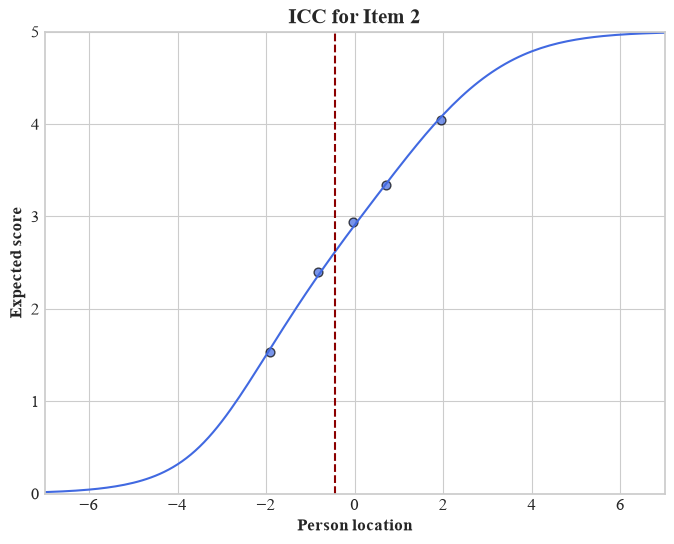

In [31]:
mfrm.icc_thresholds('Item_2', title='ICC for Item 2', obs=True, central_location=True, cat_highlight=3, xmin=-7, xmax=7, filename='my_mfrm_thresholds_icc')

Produce a set of category response curves for Item 2, with category 1 highlighted and the thresholds marked

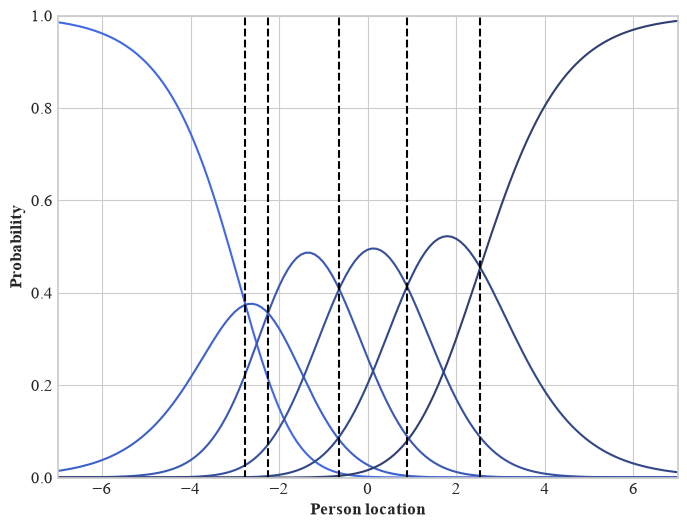

In [32]:
mfrm.crcs_thresholds('Item_2', thresh_lines=True, cat_highlight=1, xmin=-7, xmax=7, filename='my_mfrm_thresholds_crcs')

Produce a set of threshold characteristic curves for Item 2, with observed category means plotted for threshold 5, category 1 highlighted and the thresholds marked

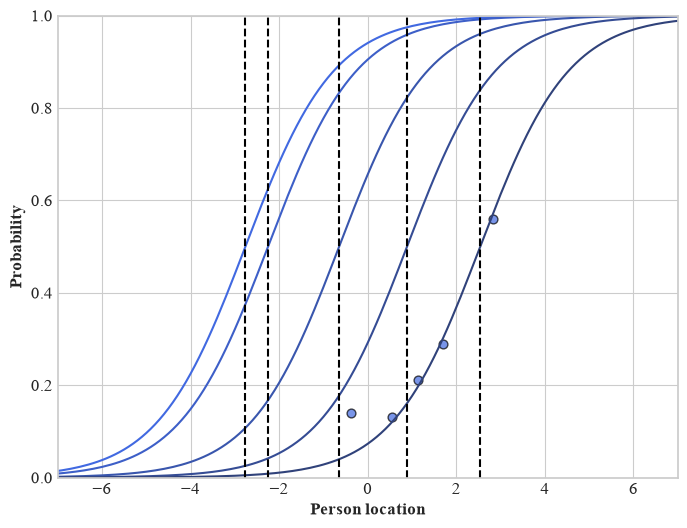

In [33]:
mfrm.threshold_ccs_thresholds('Item_2', thresh_lines=True, obs=[5], cat_highlight=1, xmin=-7, xmax=7, filename='my_mfrm_thresholds_threshold_ccs')

Produce an item information function curve for Item 2

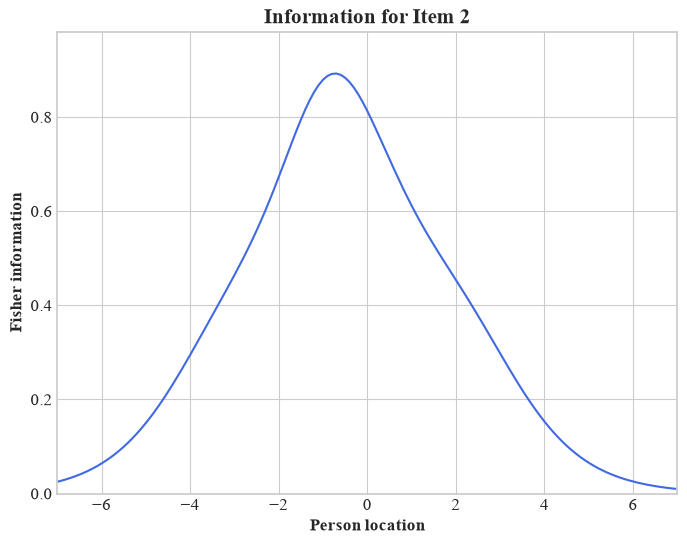

In [34]:
mfrm.iic_thresholds('Item_2', title='Information for Item 2', xmin=-7, xmax=7, filename='my_mfrm_thresholds_iic')

Produce a test characteristic curve (test response function), with person locations corresponding to scores of 20 and 30 plotted.

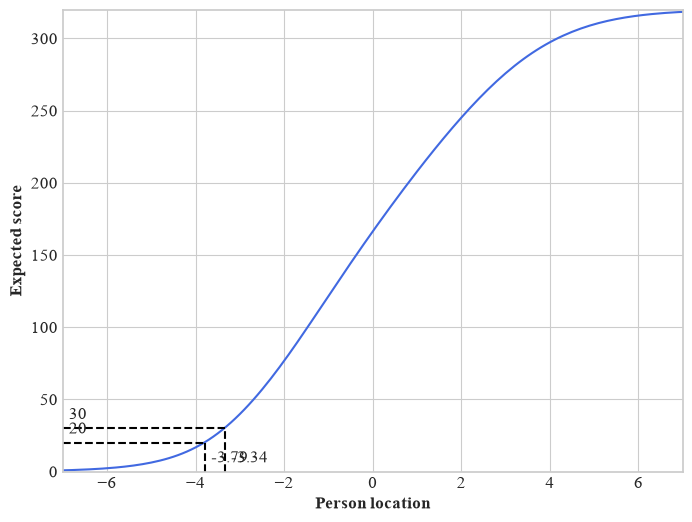

In [35]:
mfrm.tcc_thresholds(score_lines=[20, 30], score_labels=True, xmin=-7, xmax=7, filename='my_mfrm_thresholds_tcc')

Produce a test information curve

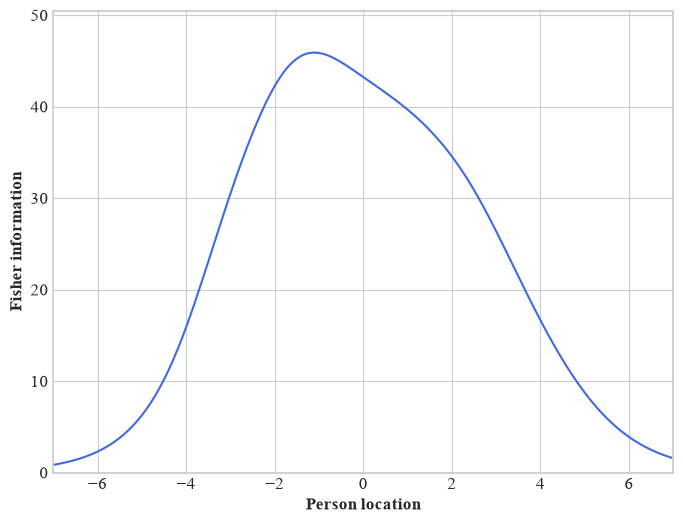

In [36]:
mfrm.test_info_thresholds(xmin=-7, xmax=7, filename='my_mfrm_thresholds_test_info_curve')

Produce a test CSEM (conditional standard error of measurement) curve, with the CSEM corresponding to a person location of -3 plotted

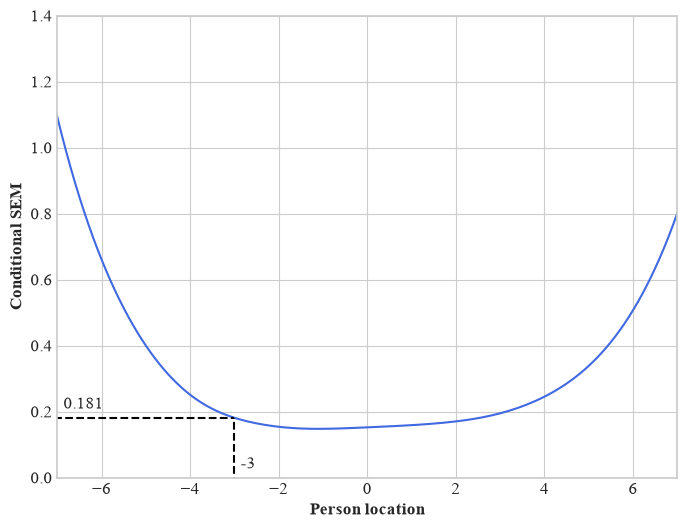

In [37]:
mfrm.test_csem_thresholds(point_csem_lines=[-3], point_csem_labels=True, ymax=1.4, xmin=-7, xmax=7, filename='my_mfrm_thresholds_csem_curve')

Produce a histogram of standardised residuals, with a normal distribution curve overlaid

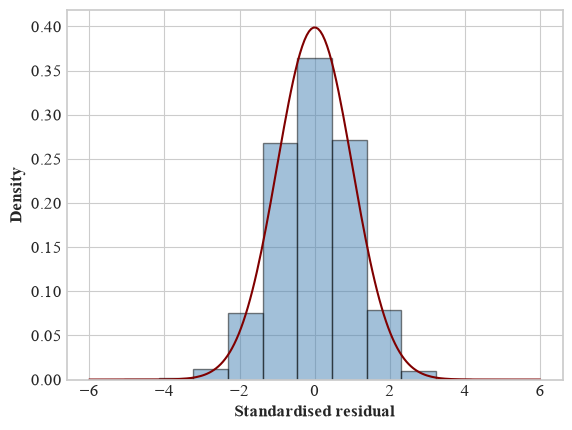

In [38]:
mfrm.std_residuals_plot_thresholds(bin_width=0.6, normal=True, filename='my_mfrm_thresholds_std_residuals_plot')

Now run an anchored analysis, anchoring to the mean severity of Raters 1-4 (e.g. a set of 'gold standard' raters).

In [39]:
%%time
anchors = ['Rater_1', 'Rater_2', 'Rater_3', 'Rater_4']
mfrm.calibrate_thresholds_anchor(anchors)

CPU times: user 764 μs, sys: 68 μs, total: 832 μs
Wall time: 778 μs


Check the anchored thresholds against the unanchored thresholds

In [40]:
mfrm.thresholds

1   -2.315967
2   -1.805084
3   -0.199239
4    1.333890
5    2.986401
dtype: float64

In [41]:
mfrm.anchor_thresholds_thresholds

1   -2.263787
2   -1.345414
3   -0.135298
4    1.140656
5    2.603843
dtype: float64

Check the anchored rater x threshold severities against the unanchored ones.

In [42]:
mfrm.raters_thresholds

,1,2,3,4,5
Rater_1,-0.583277,0.807885,-0.028583,-0.406167,-0.169196
Rater_2,0.153863,0.776572,-0.138621,0.406415,-0.883736
Rater_3,-0.192782,0.147792,-0.525040,-0.856380,-0.068941
Rater_4,0.892602,0.168113,1.009695,0.144880,-0.346676
Rater_5,0.118768,-1.176731,-0.530523,0.456316,0.353821
Rater_6,-0.368210,0.000380,0.423916,0.193513,0.220319
Rater_7,0.062674,-0.260701,0.094477,-0.030911,0.422845
Rater_8,-0.083638,-0.463310,-0.305320,0.092334,0.471563


In [43]:
mfrm.anchor_raters_thresholds

,1,2,3,4,5
Rater_1,-0.650879,0.332795,-0.107946,-0.228354,0.197942
Rater_2,0.086262,0.301481,-0.217984,0.584228,-0.516599
Rater_3,-0.260383,-0.327299,-0.604403,-0.678567,0.298196
Rater_4,0.825000,-0.306977,0.930332,0.322693,0.020461
Rater_5,0.051167,-1.651821,-0.609886,0.634129,0.720958
Rater_6,-0.435811,-0.474710,0.344553,0.371326,0.587456
Rater_7,-0.004927,-0.735791,0.015115,0.146902,0.789982
Rater_8,-0.151240,-0.938400,-0.384683,0.270147,0.838701
